In [52]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [53]:
training_data = pd.read_csv('credit_train.csv')
training_data.head(1)

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.0,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6.0,1.0,228190.0,416746.0,1.0,0.0


<Axes: >

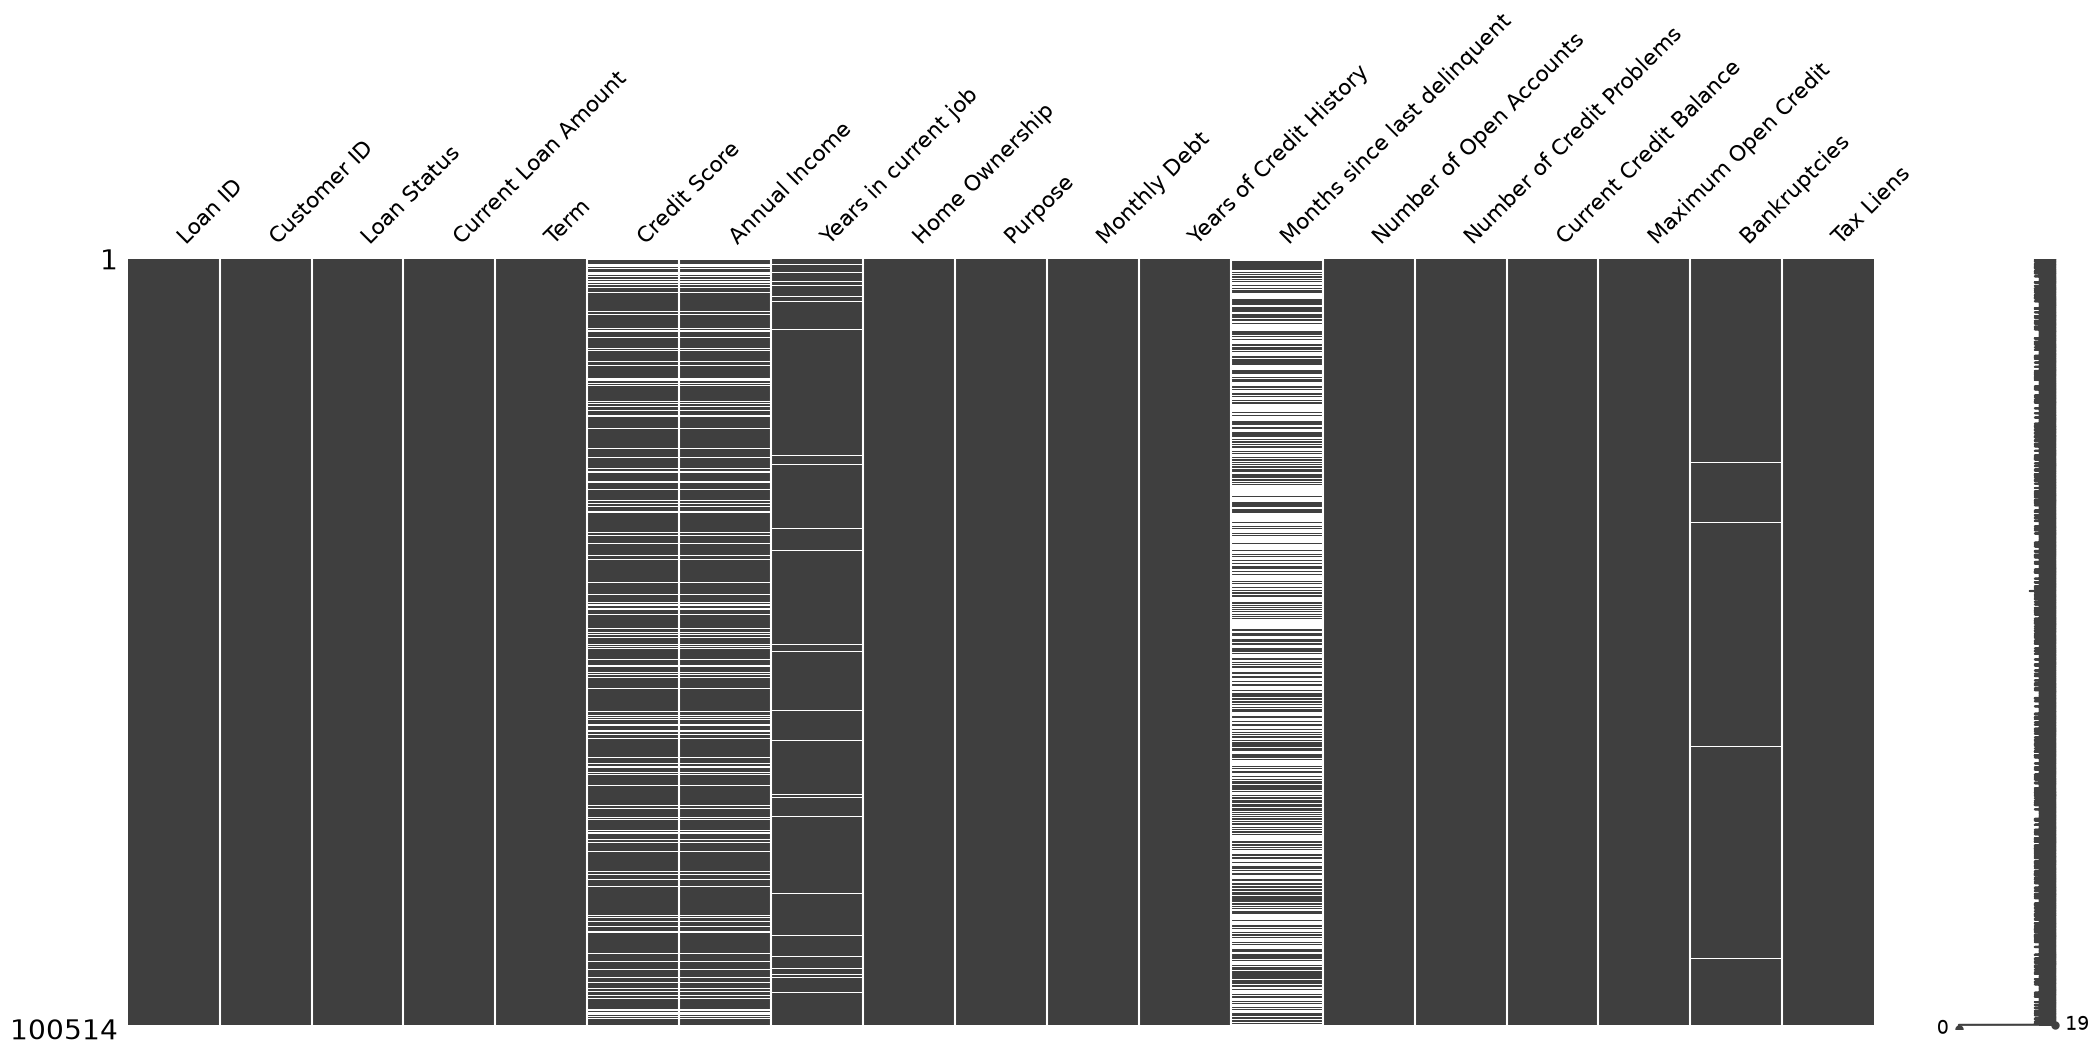

In [54]:
import missingno as msno
msno.matrix(training_data)

In [55]:
training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100514 entries, 0 to 100513
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       100000 non-null  str    
 1   Customer ID                   100000 non-null  str    
 2   Loan Status                   100000 non-null  str    
 3   Current Loan Amount           100000 non-null  float64
 4   Term                          100000 non-null  str    
 5   Credit Score                  80846 non-null   float64
 6   Annual Income                 80846 non-null   float64
 7   Years in current job          95778 non-null   str    
 8   Home Ownership                100000 non-null  str    
 9   Purpose                       100000 non-null  str    
 10  Monthly Debt                  100000 non-null  float64
 11  Years of Credit History       100000 non-null  float64
 12  Months since last delinquent  46859 non-null   float64


In [56]:
training_data.columns

Index(['Loan ID', 'Customer ID', 'Loan Status', 'Current Loan Amount', 'Term',
       'Credit Score', 'Annual Income', 'Years in current job',
       'Home Ownership', 'Purpose', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts',
       'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens'],
      dtype='str')

In [57]:
training_data.drop(columns=['Loan ID', 'Customer ID'], inplace=True)
training_data['Loan Status'].value_counts()

Loan Status
Fully Paid     77361
Charged Off    22639
Name: count, dtype: int64

In [58]:
training_data.drop_duplicates(inplace=True)
training_data.shape

(89786, 17)

In [59]:
(training_data['Months since last delinquent'].isnull().sum() * 100 / training_data.shape[0]).astype(int)

np.int64(53)

In [60]:
training_data.drop('Months since last delinquent', axis=1, inplace=True)

<Axes: xlabel='Loan Status', ylabel='Current Loan Amount'>

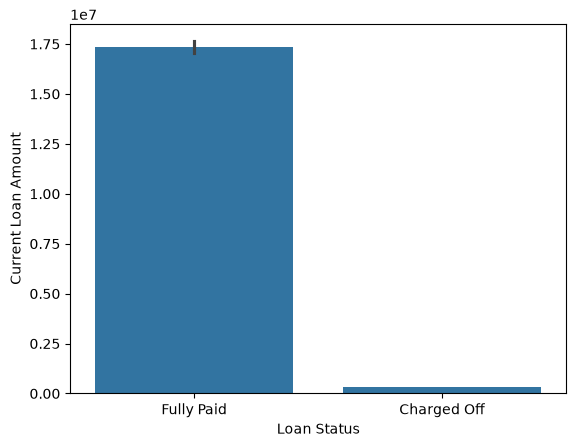

In [61]:
import seaborn as sns
sns.barplot(x=training_data['Loan Status'], y=training_data['Current Loan Amount'])

In [62]:
x = training_data.copy()
fill_list = x['Annual Income'].dropna()
x['Annual Income'] = x['Annual Income'].fillna(pd.Series(np.random.choice(fill_list, size=len(x.index))))

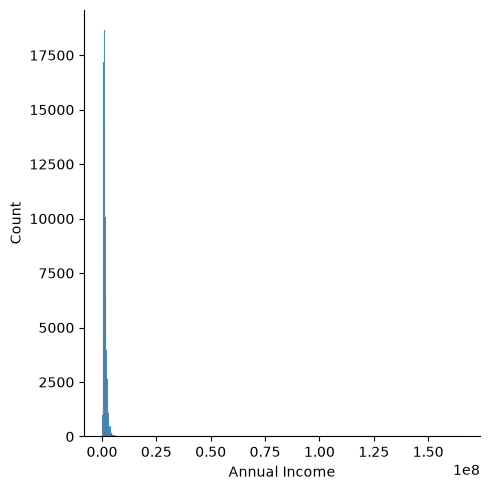

In [63]:
sns.displot(x['Annual Income'])

<Axes: >

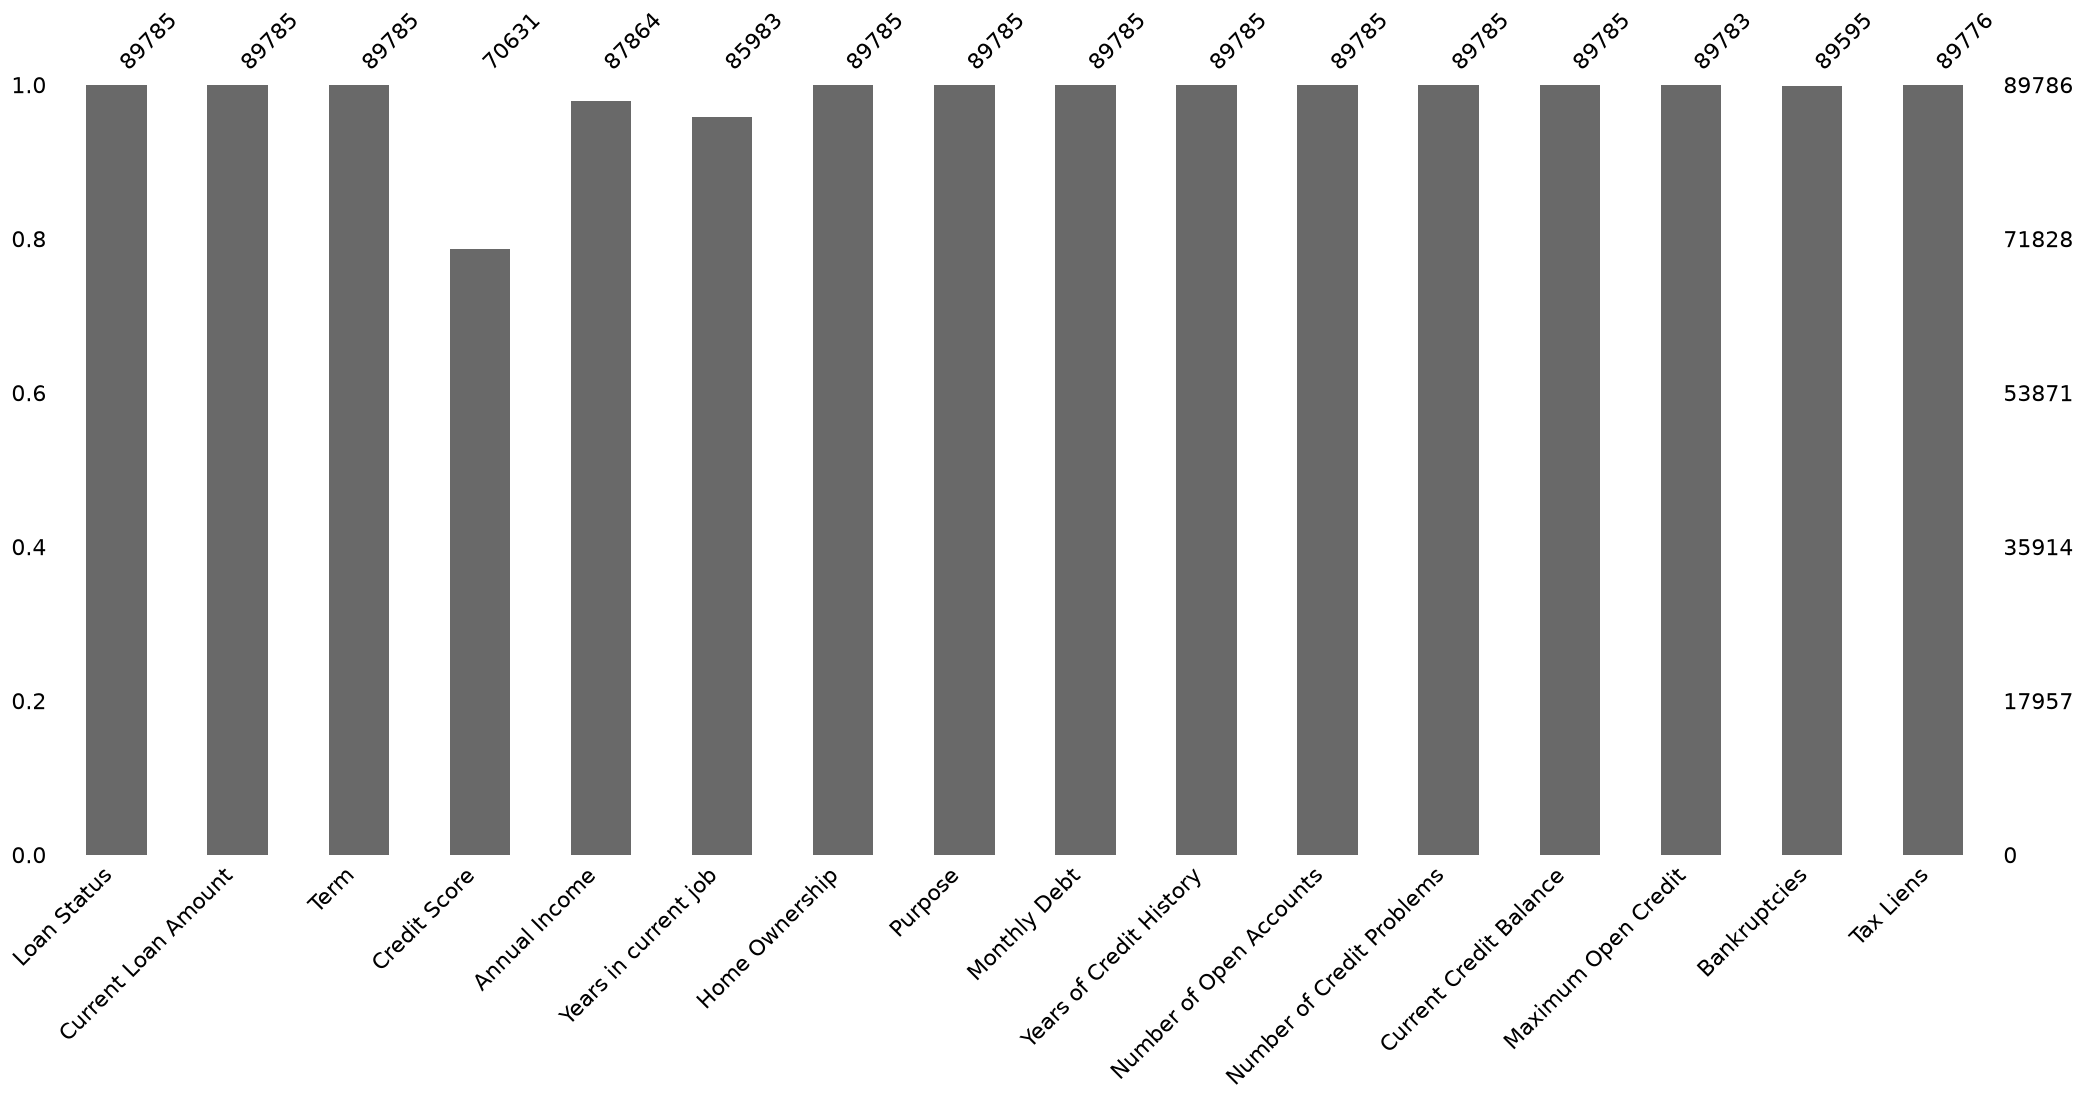

In [64]:
msno.bar(x)

In [65]:
training_data.isnull().sum()

Loan Status                      1
Current Loan Amount              1
Term                             1
Credit Score                 19155
Annual Income                19155
Years in current job          3803
Home Ownership                   1
Purpose                          1
Monthly Debt                     1
Years of Credit History          1
Number of Open Accounts          1
Number of Credit Problems        1
Current Credit Balance           1
Maximum Open Credit              3
Bankruptcies                   191
Tax Liens                       10
dtype: int64

In [66]:
fill_list = x['Credit Score'].dropna()
x['Credit Score'] = x['Credit Score'].fillna(pd.Series(np.random.choice(fill_list, size=len(x.index))))         

<Axes: xlabel='Credit Score', ylabel='Density'>

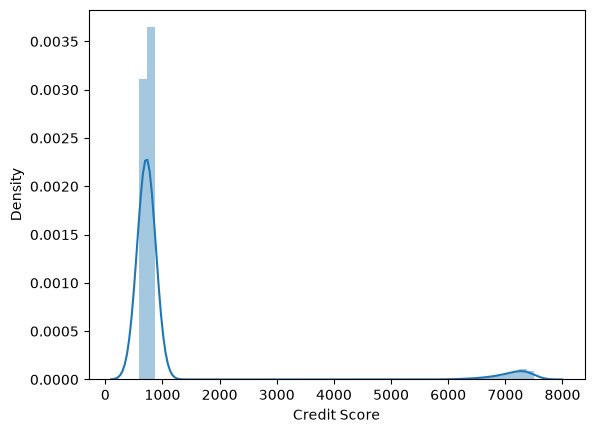

In [67]:
sns.distplot(x['Credit Score'])

<Axes: >

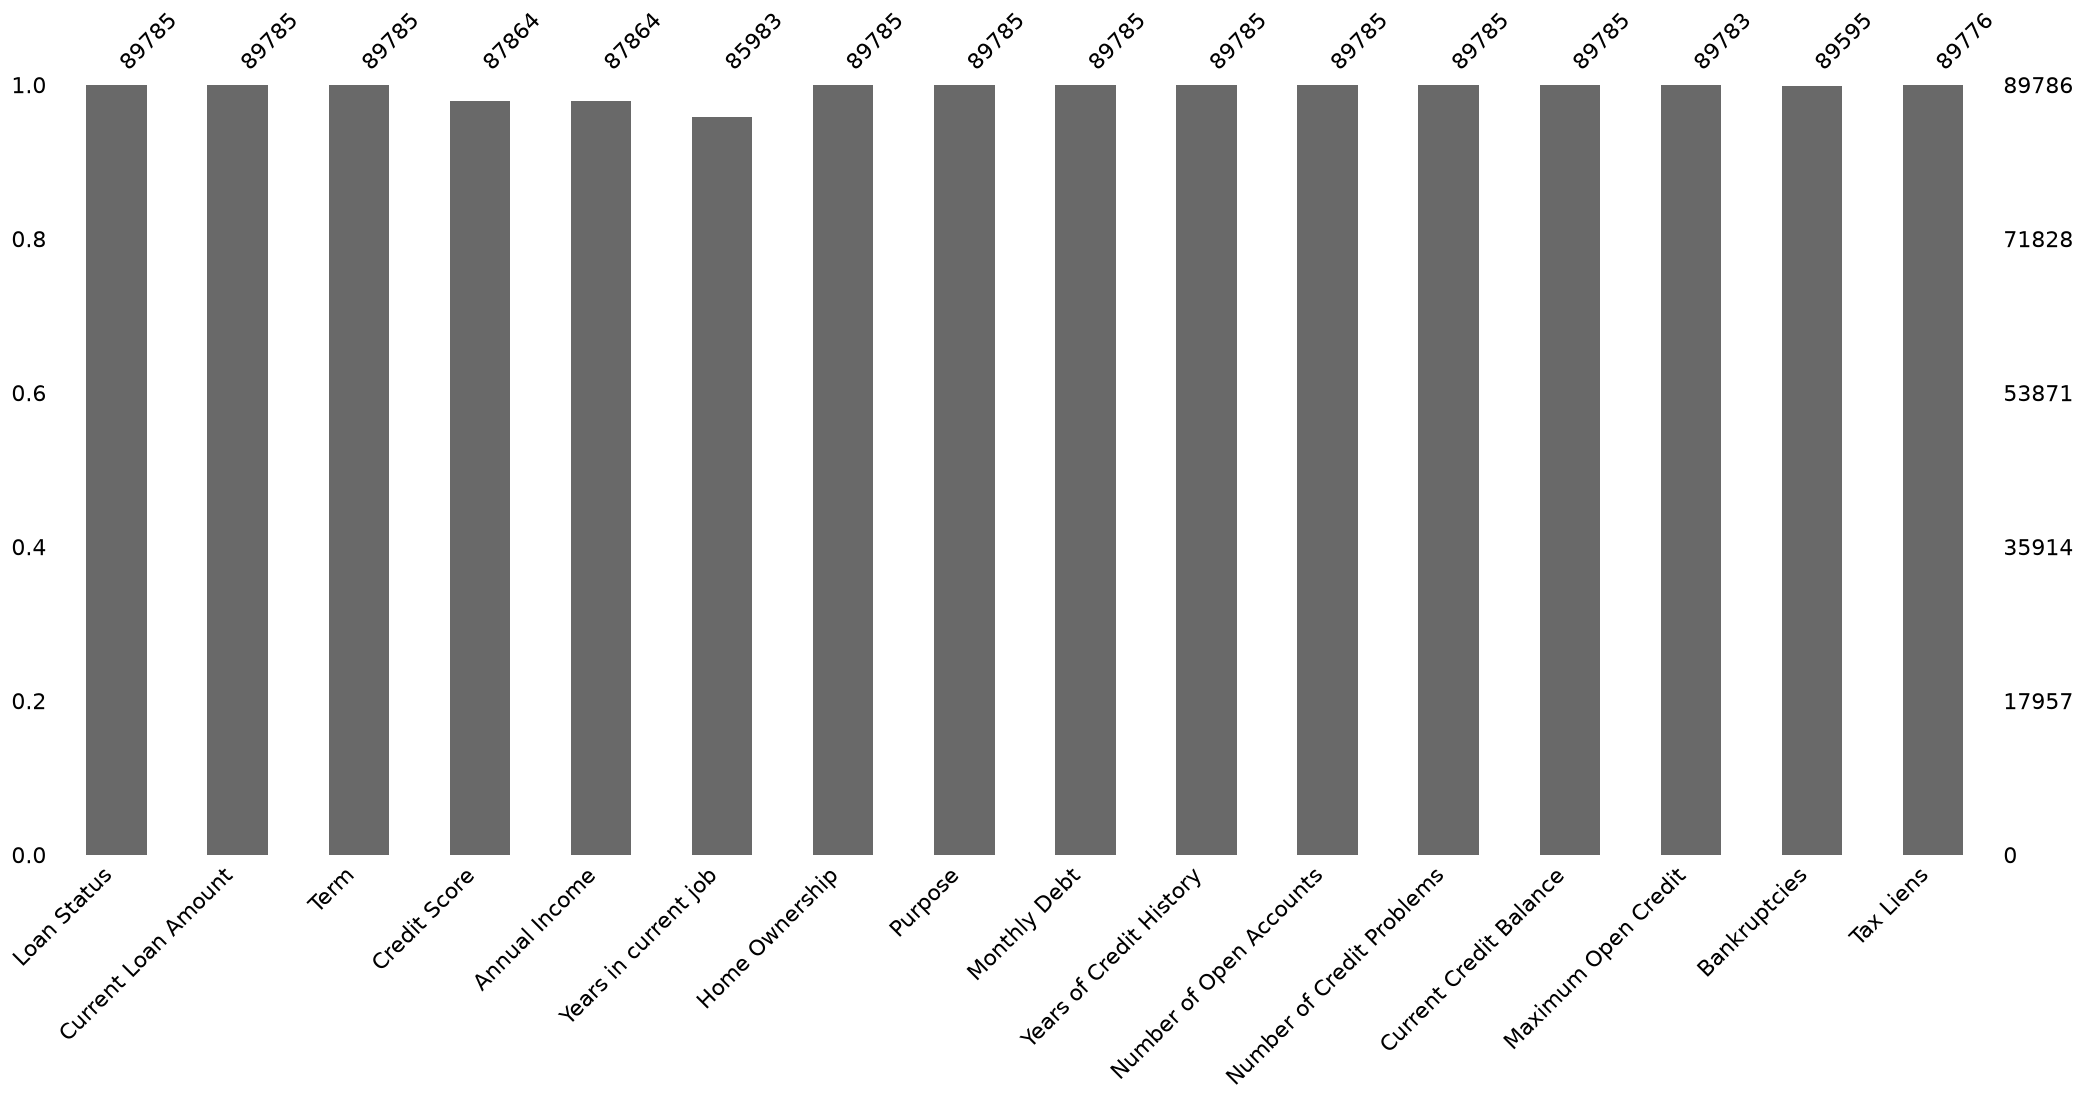

In [68]:
msno.bar(x)

In [69]:
x.dropna(subset=['Credit Score', 'Annual Income', 'Years in current job', 'Bankruptcies', 'Tax Liens', 'Maximum Open Credit'], inplace=True)
x.isnull().sum()

Loan Status                  0
Current Loan Amount          0
Term                         0
Credit Score                 0
Annual Income                0
Years in current job         0
Home Ownership               0
Purpose                      0
Monthly Debt                 0
Years of Credit History      0
Number of Open Accounts      0
Number of Credit Problems    0
Current Credit Balance       0
Maximum Open Credit          0
Bankruptcies                 0
Tax Liens                    0
dtype: int64

<Axes: >

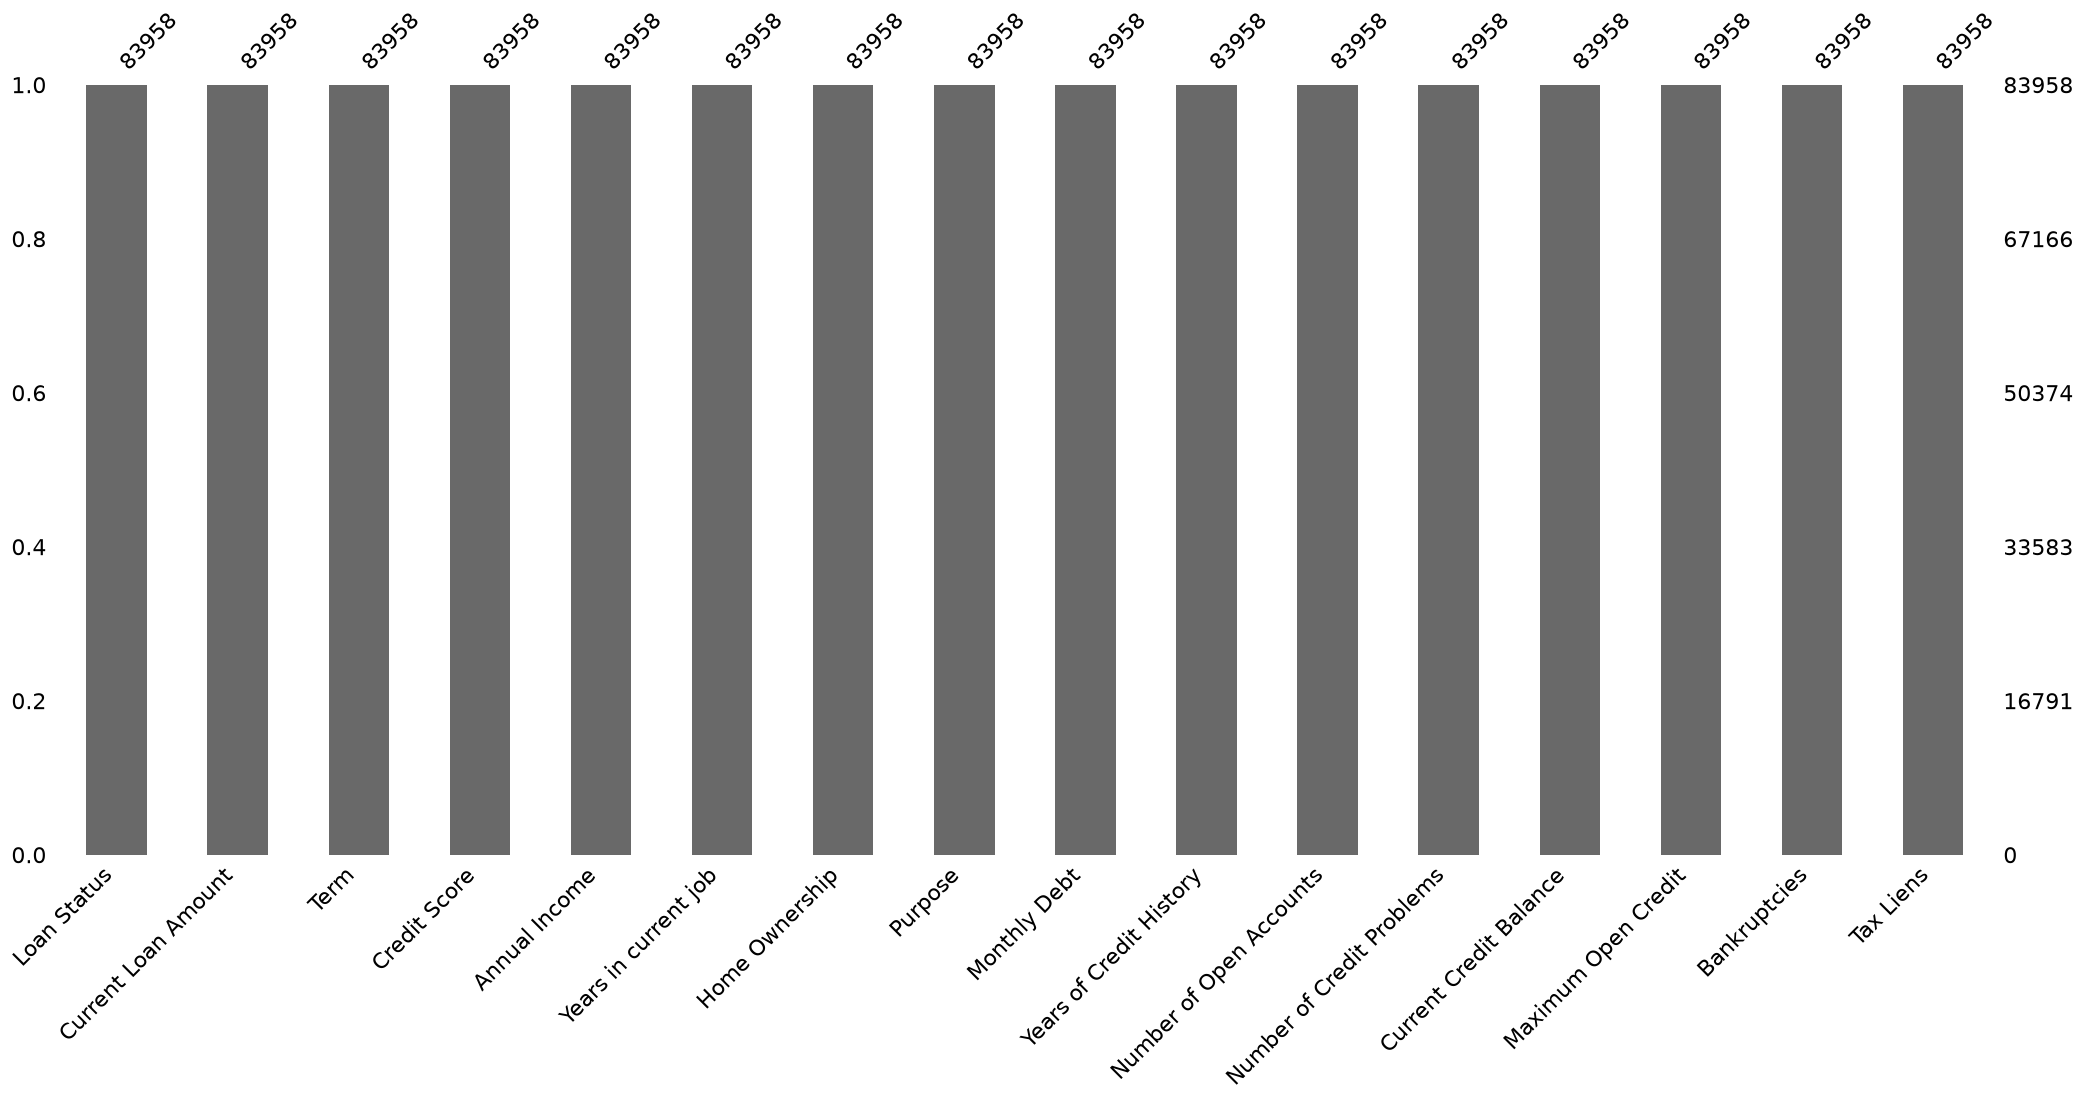

In [70]:
msno.bar(x)

In [71]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
x['Loan Status'].value_counts()

Loan Status
Fully Paid     63138
Charged Off    20820
Name: count, dtype: int64

In [72]:
categorical_columns = x.select_dtypes('object').columns
for column in categorical_columns:
    x[column] = encoder.fit_transform(x[column])

In [73]:
x.head()

,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,1,445412.0,1,709.0,1167493.0,8,1,5,5214.74,17.2,6.0,1.0,228190.0,416746.0,1.0,0.0
1,1,262328.0,1,728.0,1763124.0,1,1,3,33295.98,21.1,35.0,0.0,229976.0,850784.0,0.0,0.0
2,1,99999999.0,1,741.0,2231892.0,8,2,3,29200.53,14.9,18.0,1.0,297996.0,750090.0,0.0,0.0
3,1,347666.0,0,721.0,806949.0,3,2,3,8741.90,12.0,9.0,0.0,256329.0,386958.0,0.0,0.0
4,1,176220.0,1,712.0,2886195.0,5,3,3,20639.70,6.1,15.0,0.0,253460.0,427174.0,0.0,0.0


In [74]:
X = x.drop('Loan Status', axis=1)
y = x['Loan Status']

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((67166, 15), (16792, 15), (67166,), (16792,))

In [76]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
columns_to_scale = x.columns
columns_to_scale = columns_to_scale.drop('Loan Status')
for column in columns_to_scale:
    X_train[column] = scaler.fit_transform(X_train[column].values.reshape(-1, 1))
    X_test[column] = scaler.transform(X_test[column].values.reshape(-1, 1))


In [77]:
X_train.head()

,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
39651,-0.381898,0.608949,-0.255931,0.528915,0.075029,1.113476,-0.346497,0.073633,-0.663003,-0.236263,-0.336380,0.168060,-0.016148,-0.323274,-0.108561
78449,-0.374577,-1.642174,-0.237194,-0.631162,-1.182224,-0.978079,-0.346497,1.049945,0.612682,0.562451,-0.336380,0.670935,-0.006093,-0.323274,-0.108561
24501,2.573984,0.608949,-0.257223,0.039853,0.703655,1.113476,1.439906,0.385256,-0.340416,0.163094,1.786452,-0.209472,-0.059499,2.610525,-0.108561
32783,-0.391344,0.608949,-0.247532,-0.411674,-0.553597,1.113476,-0.346497,-0.808134,0.466052,-1.034977,-0.336380,0.036701,-0.054630,-0.323274,-0.108561
88434,-0.387097,-1.642174,-0.251408,-0.258083,-0.867911,-0.978079,-0.346497,-0.024994,-0.663003,1.960199,-0.336380,0.118324,-0.017133,-0.323274,-0.108561


In [79]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    # Input Layer
    layers.Input(shape=(X_train.shape[1],)), 
    # Hidden Layers
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    # Output Layer
    layers.Dense(1, activation='sigmoid')
])

In [80]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
X_train.shape, y_train.shape

((67166, 15), (67166,))

In [81]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10,
    restore_best_weights=True
)

In [82]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/200
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7937 - auc: 0.7176 - loss: 0.4782 - val_accuracy: 0.8005 - val_auc: 0.7471 - val_loss: 0.4545
Epoch 2/200
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7968 - auc: 0.7345 - loss: 0.4643 - val_accuracy: 0.8004 - val_auc: 0.7502 - val_loss: 0.4553
Epoch 3/200
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7970 - auc: 0.7402 - loss: 0.4611 - val_accuracy: 0.8005 - val_auc: 0.7509 - val_loss: 0.4541
Epoch 4/200
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7973 - auc: 0.7405 - loss: 0.4605 - val_accuracy: 0.8004 - val_auc: 0.7524 - val_loss: 0.4527
Epoch 5/200
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7966 - auc: 0.7432 - loss: 0.4597 - val_accuracy: 0.8005 - val_auc: 0.7536 - val_loss: 0.4528
Epoch 6/200
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7972 - auc: 0.7458 - loss: 0.4589 - val_accuracy: 0.8005 - val_auc: 0.7525 - val_loss: 0.4518
Epoch 7/200
2099/2099 

In [83]:
test_loss, test_accuracy, test_auc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test AUC: {test_auc:.3f}")

525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - accuracy: 0.8009 - auc: 0.7583 - loss: 0.4478
Test accuracy: 80.09%
Test AUC: 0.758


In [84]:
train_loss, train_accuracy, train_auc = model.evaluate(X_train, y_train)
print(f"Train accuracy: {train_accuracy * 100:.2f}%")
print(f"Train AUC: {train_auc:.3f}")

2099/2099 ━━━━━━━━━━━━━━━━━━━━ 2s 747us/step - accuracy: 0.7980 - auc: 0.7622 - loss: 0.4488
Train accuracy: 79.80%
Train AUC: 0.762


In [85]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [86]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [90]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_confusion = confusion_matrix(y_train, y_train_pred)


In [91]:
train_confusion

array([[ 3620, 13036],
       [  593, 49917]])

In [92]:
train_precision, train_recall, train_f1

(0.7929248804663797, 0.9882597505444466, 0.8798815472885434)

In [94]:
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)

In [95]:
test_confusion

array([[  973,  3191],
       [  160, 12468]])

In [96]:
test_recall, test_precision, test_f1

(0.9873297434273044, 0.7962194265278754, 0.8815356877717679)